# Semantic Primitives — Experiment Zero
Testing whether intuited primitives are spread out in embedding space.

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

primitives = ['heat', 'cold', 'water', 'air', 'solid', 'soft', 'dark', 'light',
              'up', 'down', 'fast', 'slow', 'alive', 'dead', 'self', 'other']

embeddings = model.encode(primitives)
print(f'Embedding shape: {embeddings.shape}  ({embeddings.shape[1]} dimensions per word)')

/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (16, 384)  (384 dimensions per word)


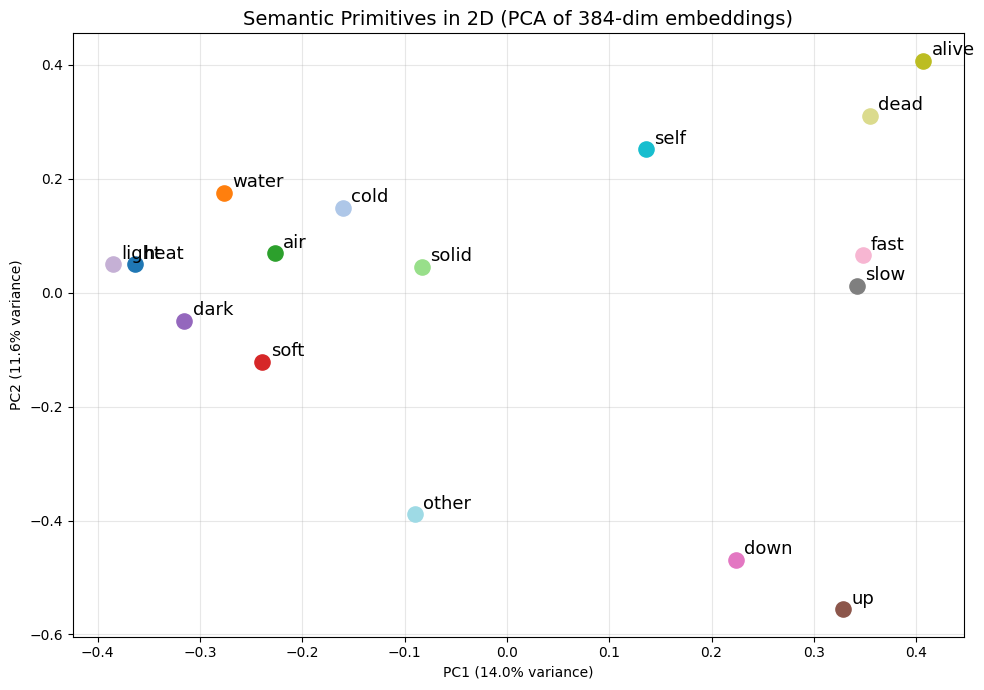

Saved: primitives_scatter.png


In [2]:
# --- 2D scatter plot ---
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 7))
colors = cm.tab20(np.linspace(0, 1, len(primitives)))

for i, word in enumerate(primitives):
    ax.scatter(*coords[i], color=colors[i], s=120, zorder=3)
    ax.annotate(word, coords[i], fontsize=13, textcoords='offset points', xytext=(6, 4))

ax.set_title('Semantic Primitives in 2D (PCA of 384-dim embeddings)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/ryanfunk/primitives_scatter.png', dpi=150)
plt.show()
print('Saved: primitives_scatter.png')

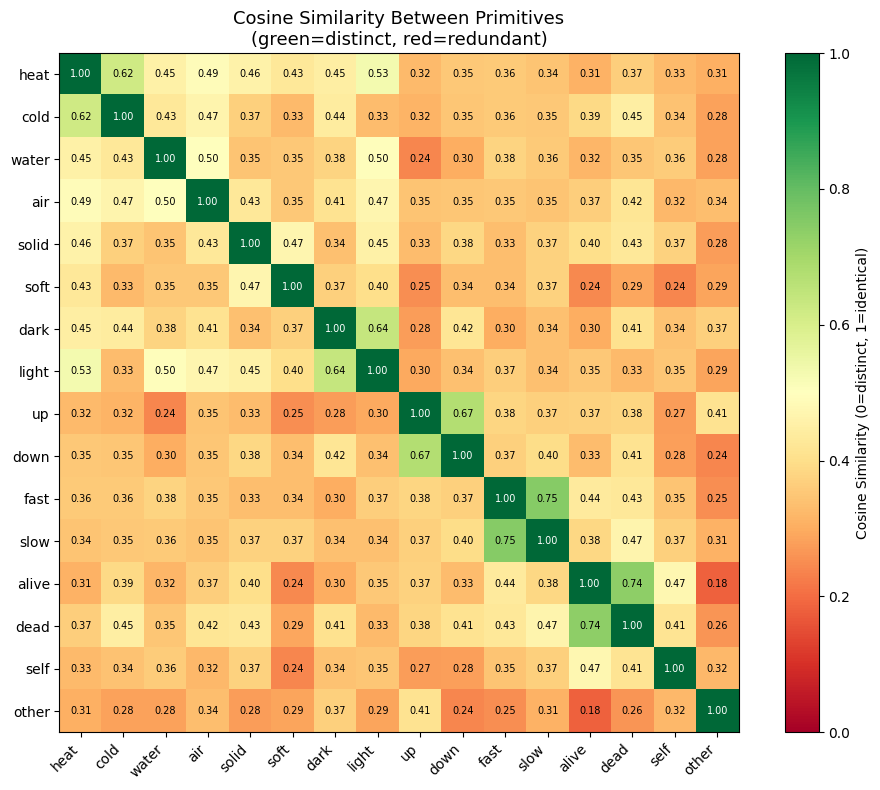

Saved: primitives_heatmap.png


In [3]:
# --- Cosine similarity heatmap: are primitives actually distinct? ---
sim = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity (0=distinct, 1=identical)')
ax.set_xticks(range(len(primitives)))
ax.set_yticks(range(len(primitives)))
ax.set_xticklabels(primitives, rotation=45, ha='right')
ax.set_yticklabels(primitives)

for i in range(len(primitives)):
    for j in range(len(primitives)):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if sim[i,j] < 0.8 else 'white')

ax.set_title('Cosine Similarity Between Primitives\n(green=distinct, red=redundant)', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/ryanfunk/primitives_heatmap.png', dpi=150)
plt.show()
print('Saved: primitives_heatmap.png')

In [4]:
# --- Composition test: does primitive math work? ---
combos = [
    ('water', 'air',   'cloud'),
    ('water', 'cold',  'ice'),
    ('heat',  'air',   'fire'),
    ('alive', 'self',  'person'),
    ('dark',  'solid', 'rock'),
]

word_map = {w: embeddings[i] for i, w in enumerate(primitives)}

print('Composition test — nearest neighbors to (A + B):\n')
targets = list(primitives)
for a, b, expected in combos:
    combo_vec = (word_map[a] + word_map[b]) / 2
    sims = cosine_similarity([combo_vec], embeddings)[0]
    ranked = sorted(zip(primitives, sims), key=lambda x: -x[1])
    top3 = [(w, f'{s:.3f}') for w, s in ranked[:3]]
    print(f'  {a} + {b} → expect [{expected}]  |  top matches: {top3}')

Composition test — nearest neighbors to (A + B):

  water + air → expect [cloud]  |  top matches: [('air', '0.866'), ('water', '0.866'), ('light', '0.559')]
  water + cold → expect [ice]  |  top matches: [('water', '0.845'), ('cold', '0.845'), ('heat', '0.633')]
  heat + air → expect [fire]  |  top matches: [('heat', '0.863'), ('air', '0.863'), ('cold', '0.629')]
  alive + self → expect [person]  |  top matches: [('alive', '0.858'), ('self', '0.858'), ('dead', '0.671')]
  dark + solid → expect [rock]  |  top matches: [('solid', '0.818'), ('dark', '0.818'), ('light', '0.669')]


/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ryanfunk/Library/Python/3.9/lib/python/site-packages/sklearn/util